In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import njit
from scipy.optimize import minimize
from scipy.stats import shapiro, jarque_bera, probplot

plt.style.use("ggplot")
np.random.seed(52)

#### 1. Основные классы

In [3]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state=None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state

    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0.0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1.0

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0.0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0.0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0.0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0.0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0.0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt=None):
        dt = self.T / self.Nt
        t_data = np.linspace(0.0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0.0, 1.0, size=(self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_prev = x_data[i - 1]
            t_prev = t_data[i - 1]
            x_data[i] = (
                x_prev
                + self.bxt(x_prev, t_prev, self.params) * dt
                + self.sigmaxt(x_prev, t_prev, self.params) * dwt[i - 1]
            )
        return t_data, x_data

    @staticmethod
    @njit
    def EulerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        mean_x = x0 + bxt(x0, t0, params) * (t - t0)
        var_x = sigmaxt(x0, t0, params) ** 2 * (t - t0)

        if var_x <= 0.0:
            var_x = 1e-8

        return -0.5 * np.log(2.0 * np.pi * var_x) - (x - mean_x) ** 2 / (2.0 * var_x)

    @staticmethod
    @njit
    def ShojiOzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        L = bxt_x(x0, t0, params)
        if np.abs(L) < 1e-8:
            L = 1e-3

        M = 0.5 * sigmaxt(x0, t0, params) ** 2 * bxt_xx(x0, t0, params) + bxt_t(x0, t0, params)

        A = (
            1.0
            + bxt(x0, t0, params) / (x0 * L) * (np.exp(L * (t - t0)) - 1.0)
            + M / (x0 * L**2) * (np.exp(L * (t - t0)) - 1.0 - L * (t - t0))
        )
        B = sigmaxt(x0, t0, params) ** 2 * (np.exp(2.0 * L * (t - t0)) - 1.0) / (2.0 * L)

        mean_x = A * x0
        var_x = B

        if var_x <= 0.0:
            var_x = 1e-8

        return -0.5 * np.log(2.0 * np.pi * var_x) - (x - mean_x) ** 2 / (2.0 * var_x)

    @staticmethod
    @njit
    def KesslerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        dt = t - t0

        mean_x = (
            x0
            + bxt(x0, t0, params) * dt
            + 0.5 * (
                bxt(x0, t0, params) * bxt_x(x0, t0, params)
                + 0.5 * sigmaxt(x0, t0, params) ** 2 * bxt_xx(x0, t0, params)
            ) * dt**2
        )

        second_moment = (
            x0**2
            + (2.0 * bxt(x0, t0, params) * x0 + sigmaxt(x0, t0, params) ** 2) * dt
            + 0.5 * (
                2.0 * bxt(x0, t0, params) * (
                    bxt_x(x0, t0, params) * x0
                    + bxt(x0, t0, params)
                    + sigmaxt(x0, t0, params) * sigmaxt_x(x0, t0, params)
                )
                + sigmaxt(x0, t0, params) ** 2 * (
                    bxt_xx(x0, t0, params) * x0
                    + 2.0 * bxt_x(x0, t0, params)
                    + sigmaxt_x(x0, t0, params) ** 2
                    + sigmaxt(x0, t0, params) * sigmaxt_xx(x0, t0, params)
                )
            ) * dt**2
        )

        var_x = second_moment - mean_x**2
        if var_x <= 0.0:
            var_x = 1e-8

        return -0.5 * np.log(2.0 * np.pi * var_x) - (x - mean_x) ** 2 / (2.0 * var_x)

    @staticmethod
    @njit
    def MLogLik(params, t_data, x_data, density, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        Nt = len(x_data)
        Nx = len(x_data[0])

        loglik_values = np.zeros(Nx)

        for k in range(Nx):
            current_loglik = 0.0
            for j in range(1, Nt):
                current_loglik += density(
                    x_data[j][k],
                    t_data[j],
                    x_data[j - 1][k],
                    t_data[j - 1],
                    params,
                    bxt, bxt_x, bxt_xx,
                    sigmaxt, sigmaxt_x, sigmaxt_xx,
                    bxt_t
                )
            loglik_values[k] = current_loglik

        return -np.mean(loglik_values)

    def EulerEstimation(self, t_data, x_data):
        initial_guess = np.ones(len(self.params))
        return minimize(
            self.MLogLik,
            x0=initial_guess,
            args=(
                t_data, x_data, self.EulerDensity,
                self.bxt, self.bxt_x, self.bxt_xx,
                self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                self.bxt_t
            ),
            method="L-BFGS-B",
            options={"ftol": 1e-8, "eps": 1e-8}
        )

    def ShojiOzakiEstimation(self, t_data, x_data):
        initial_guess = np.ones(len(self.params))
        return minimize(
            self.MLogLik,
            x0=initial_guess,
            args=(
                t_data, x_data, self.ShojiOzakiDensity,
                self.bxt, self.bxt_x, self.bxt_xx,
                self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                self.bxt_t
            ),
            method="L-BFGS-B",
            options={"ftol": 1e-8, "eps": 1e-8}
        )

    def KesslerEstimation(self, t_data, x_data):
        initial_guess = np.ones(len(self.params))
        return minimize(
            self.MLogLik,
            x0=initial_guess,
            args=(
                t_data, x_data, self.KesslerDensity,
                self.bxt, self.bxt_x, self.bxt_xx,
                self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                self.bxt_t
            ),
            method="L-BFGS-B",
            options={"ftol": 1e-8, "eps": 1e-8}
        )

In [4]:
class BMprocess(StochasticProcess):
    # params = [mu, sigma]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0]

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1]


class BSMprocess(StochasticProcess):
    # params = [mu, sigma]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]


class OUprocess(StochasticProcess):
    # params = [kappa, mu, sigma]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * (params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]


class CIRprocess(StochasticProcess):
    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] - params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * np.sqrt(max(x, 1e-8))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] / (2.0 * np.sqrt(max(x, 1e-8)))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        x_safe = max(x, 1e-8)
        return -params[2] / (4.0 * x_safe ** 1.5)


class CEVprocess(StochasticProcess):
    # params = [mu, sigma, gamma]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * (max(x, 1e-8) ** params[2])

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        x_safe = max(x, 1e-8)
        return params[1] * params[2] * (x_safe ** (params[2] - 1.0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        x_safe = max(x, 1e-8)
        return params[1] * params[2] * (params[2] - 1.0) * (x_safe ** (params[2] - 2.0))


class CKLSprocess(StochasticProcess):
    # params = [theta1, theta2, theta3, theta4]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] + params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * (max(x, 1e-8) ** params[3])

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        x_safe = max(x, 1e-8)
        return params[2] * params[3] * (x_safe ** (params[3] - 1.0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        x_safe = max(x, 1e-8)
        return params[2] * params[3] * (params[3] - 1.0) * (x_safe ** (params[3] - 2.0))

#### 2. Загрузка и очистка датасета

In [6]:
data_path = "data/Project_1_DGS10.csv"

rates_df = pd.read_csv(data_path)

rates_df["DATE"] = pd.to_datetime(rates_df["DATE"])
rates_df["DGS10"] = rates_df["DGS10"].replace(".", np.nan)
rates_df["DGS10"] = pd.to_numeric(rates_df["DGS10"], errors="coerce")

rates_df = (
    rates_df
    .dropna(subset=["DGS10"])
    .sort_values("DATE")
    .reset_index(drop=True)
)

rates_df.rename(columns={"DGS10": "rate"}, inplace=True)

rates_df.head(), rates_df.tail()

(        DATE  rate
 0 2019-11-07  1.92
 1 2019-11-08  1.94
 2 2019-11-12  1.92
 3 2019-11-13  1.88
 4 2019-11-14  1.82,
            DATE  rate
 1247 2024-11-01  4.37
 1248 2024-11-04  4.31
 1249 2024-11-05  4.26
 1250 2024-11-06  4.42
 1251 2024-11-07  4.31)

In [28]:
# basic series + increment data
rates_df["rate_diff"] = rates_df["rate"].diff()
rates_df["rate_pct_change"] = rates_df["rate"].pct_change()

analysis_df = rates_df.dropna().copy()

print(f"number of observations: {len(rates_df)}")

number of observations: 1252


#### 3. Статистический анализ

In [29]:
change_mean = analysis_df["rate_diff"].mean()
change_var = analysis_df["rate_diff"].var(ddof=1)

q1 = analysis_df["rate_diff"].quantile(0.25)
q3 = analysis_df["rate_diff"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_df = analysis_df[
    (analysis_df["rate_diff"] < lower_bound) |
    (analysis_df["rate_diff"] > upper_bound)
].copy()

print(f"daily changes mean: {change_mean:.6f}")
print(f"daily changes variance: {change_var:.6f}")
print(f"num of outliers: {len(outliers_df)}")

daily changes mean: 0.001910
daily changes variance: 0.003941
num of outliers: 45


In [30]:
# cusum change-point statistic on daily changes
change_values = analysis_df["rate_diff"].values
change_centered = change_values - change_values.mean()

cusum_values = np.cumsum(change_centered)
cusum_values = cusum_values / (np.std(change_values, ddof=1) * np.sqrt(len(change_values)))

change_idx = np.argmax(np.abs(cusum_values))
change_date = analysis_df["DATE"].iloc[change_idx]

print(f"Estimated main change point date: {change_date.date()}")

Estimated main change point date: 2020-08-04


In [31]:
# normality checks
shapiro_stat, shapiro_p = shapiro(analysis_df["rate_diff"].sample(min(5000, len(analysis_df)), random_state=52))
jb_stat, jb_p = jarque_bera(analysis_df["rate_diff"])

print(f"Shapiro-Wilk p-value: {shapiro_p:.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

Shapiro-Wilk p-value: 0.000000
Jarque-Bera p-value: 0.000000


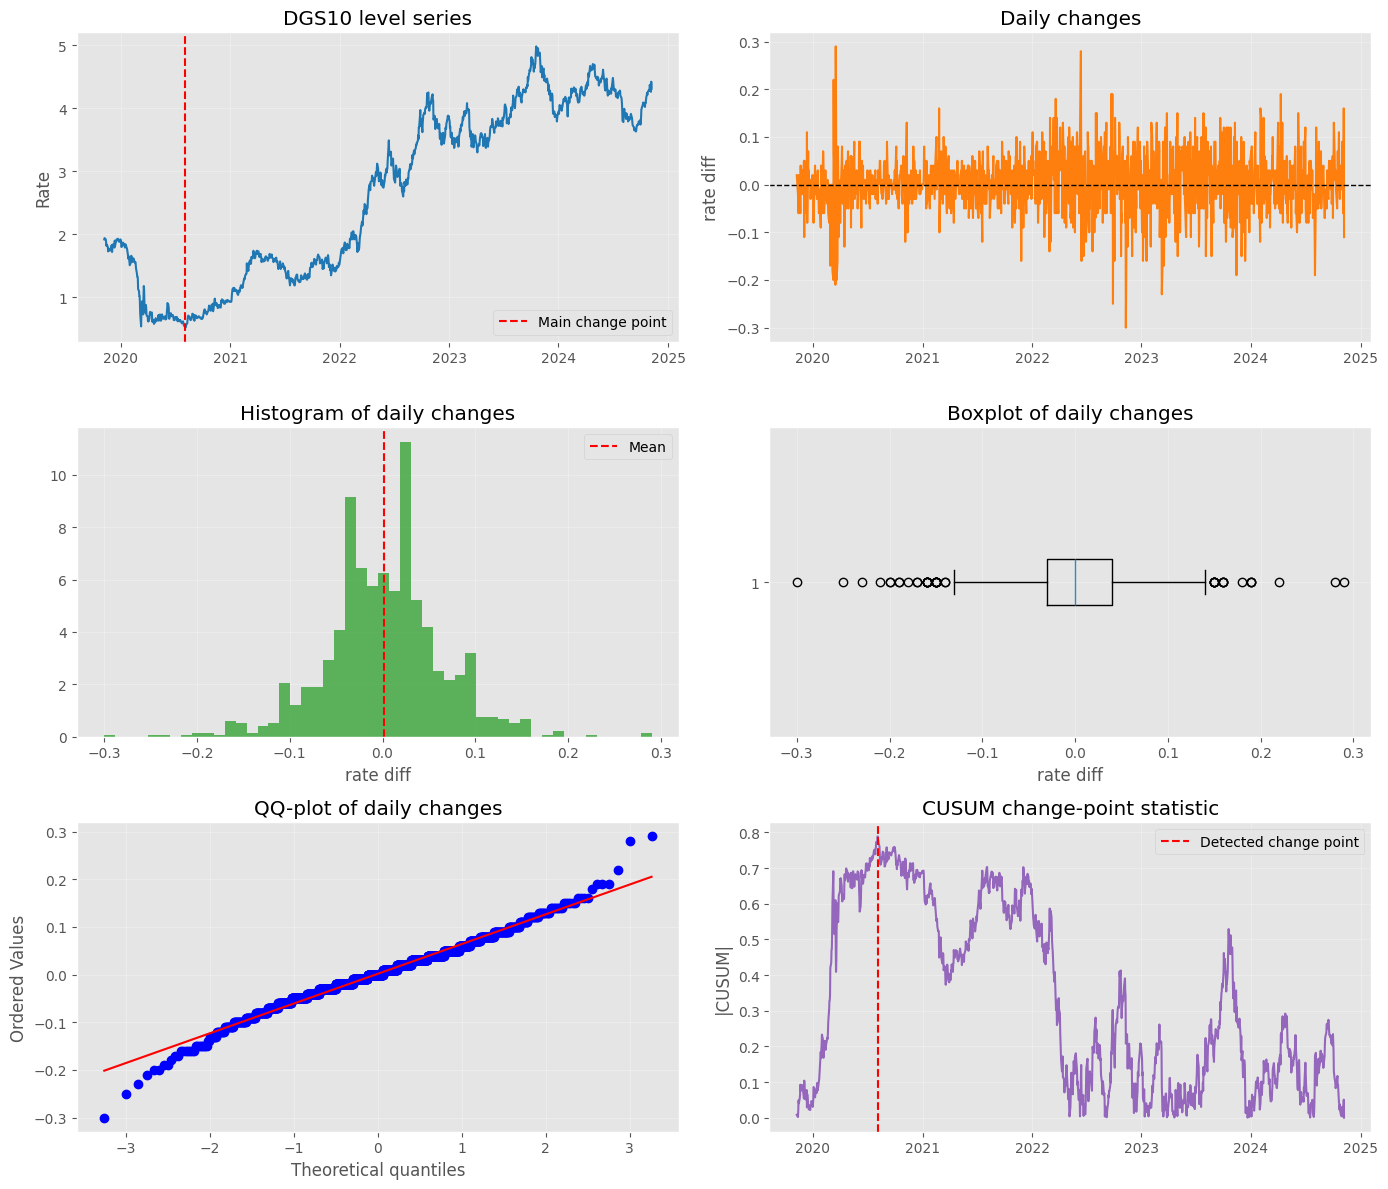

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# rate level
axes[0, 0].plot(rates_df["DATE"], rates_df["rate"], color="tab:blue")
axes[0, 0].axvline(change_date, color="red", linestyle="--", label="Main change point")
axes[0, 0].set_title("DGS10 level series")
axes[0, 0].set_ylabel("Rate")
axes[0, 0].legend()

# daily changes
axes[0, 1].plot(analysis_df["DATE"], analysis_df["rate_diff"], color="tab:orange")
axes[0, 1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set_title("Daily changes")
axes[0, 1].set_ylabel("rate diff")

# histogram of changes
axes[1, 0].hist(analysis_df["rate_diff"], bins=50, density=True, alpha=0.75, color="tab:green")
axes[1, 0].axvline(change_mean, color="red", linestyle="--", label="Mean")
axes[1, 0].set_title("Histogram of daily changes")
axes[1, 0].set_xlabel("rate diff")
axes[1, 0].legend()

# boxplot for outliers
axes[1, 1].boxplot(analysis_df["rate_diff"], vert=False)
axes[1, 1].set_title("Boxplot of daily changes")
axes[1, 1].set_xlabel("rate diff")

# QQ-plot
probplot(analysis_df["rate_diff"], dist="norm", plot=axes[2, 0])
axes[2, 0].set_title("QQ-plot of daily changes")

# CUSUM statistic
axes[2, 1].plot(analysis_df["DATE"], np.abs(cusum_values), color="tab:purple")
axes[2, 1].axvline(change_date, color="red", linestyle="--", label="Detected change point")
axes[2, 1].set_title("CUSUM change-point statistic")
axes[2, 1].set_ylabel("|CUSUM|")
axes[2, 1].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 4. Подготовка моделей и шага дискретизации

Фиксируем шаг дискретизации для дневных данных, формируем наблюдаемую траекторию в формате, подходящем для MLE, и создаем набор моделей, которые будут оцениваться тремя методами- Эйлер, Озаки, Кесслер

In [33]:
dt = 1.0 / 252.0

observed_rates = rates_df["rate"].values.astype(float)
n_obs = len(observed_rates)

time_grid_mle = np.arange(n_obs) * dt
path_data_mle = observed_rates.reshape(-1, 1)

T_mle = (n_obs - 1) * dt
Nt_mle = n_obs - 1
Nx_mle = 1
initial_state_mle = np.array([observed_rates[0]])

# dummy param vectors are used only to define model dimension
model_specs = [
    ("BM", BMprocess(np.ones(2), T_mle, Nx_mle, Nt_mle, initial_state_mle)),
    ("GBM", BSMprocess(np.ones(2), T_mle, Nx_mle, Nt_mle, initial_state_mle)),
    ("OU", OUprocess(np.ones(3), T_mle, Nx_mle, Nt_mle, initial_state_mle)),
    ("CIR", CIRprocess(np.ones(3), T_mle, Nx_mle, Nt_mle, initial_state_mle)),
    ("CEV", CEVprocess(np.ones(3), T_mle, Nx_mle, Nt_mle, initial_state_mle)),
    ("CKLS", CKLSprocess(np.ones(4), T_mle, Nx_mle, Nt_mle, initial_state_mle)),
]

print(f"time step dt: {dt:.6f}")
print(f"total horizon T: {T_mle:.2f}")

time step dt: 0.003968
total horizon T: 4.96


#### 5. Оценивание параметров оригинальным кодом

Для каждой модели запускаются три метода оценивания: Эйлер, Озаки, Кесслер. Результаты сохраняем в общую таблицу вместе со статусом оптимизации

In [34]:
def run_estimation(method_name, process, time_grid, path_data):
    """ Run one estimation method and return a compact result dict""" 
    if method_name == "Euler":
        result = process.EulerEstimation(time_grid, path_data)
    elif method_name == "Shoji-Ozaki":
        result = process.ShojiOzakiEstimation(time_grid, path_data)
    elif method_name == "Kessler":
        result = process.KesslerEstimation(time_grid, path_data)
    else:
        raise ValueError("Unknown estimation method")

    estimated = np.full(4, np.nan)
    estimated[:len(result.x)] = result.x

    return {
        "success": bool(result.success),
        "status": int(result.status),
        "message": result.message,
        "neg_loglik": float(result.fun),
        "theta_1": estimated[0],
        "theta_2": estimated[1],
        "theta_3": estimated[2],
        "theta_4": estimated[3],
    }


estimation_rows = []
estimation_methods = ["Euler", "Shoji-Ozaki", "Kessler"]

for model_name, process in model_specs:
    for method_name in estimation_methods:
        estimation_output = run_estimation(method_name, process, time_grid_mle, path_data_mle)

        estimation_rows.append({
            "Model": model_name,
            "Method": method_name,
            **estimation_output
        })

estimation_results_df = pd.DataFrame(estimation_rows)
estimation_results_df

,Model,Method,success,status,message,neg_loglik,theta_1,theta_2,theta_3,theta_4
0,BM,Euler,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1688.391476,0.481404,0.996148,NaN,NaN
1,BM,Shoji-Ozaki,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1688.391475,0.481017,0.996147,NaN,NaN
2,BM,Kessler,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1688.391471,0.482739,0.996145,NaN,NaN
3,GBM,Euler,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1356.425169,0.336802,0.594605,NaN,NaN
4,GBM,Shoji-Ozaki,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1356.425169,0.336542,0.594209,NaN,NaN
5,GBM,Kessler,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1356.425169,0.336591,0.593608,NaN,NaN
6,OU,Euler,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1688.376094,-0.010008,-43.664130,0.997163,NaN
7,OU,Shoji-Ozaki,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1688.378613,-0.008280,-53.168451,0.995261,NaN
8,OU,Kessler,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1688.359030,-0.023297,-17.940942,0.995920,NaN
9,CIR,Euler,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,-1670.551106,0.803518,0.123174,0.683672,NaN


#### 6. Сводная таблица параметров

Компактная таблица с оценками параметров для каждой модели и каждого метода. Эта таблица будет основной для следующего этапа, где добавятся критерии AIC и BIC и будет выбираться лучшая модель

In [36]:
parameter_summary_df = estimation_results_df[
    ["Model", "Method", "theta_1", "theta_2", "theta_3", "theta_4", "neg_loglik", "success"]
].copy()

parameter_summary_df = parameter_summary_df.sort_values(["Model", "Method"]).reset_index(drop=True)
parameter_summary_df

,Model,Method,theta_1,theta_2,theta_3,theta_4,neg_loglik,success
0,BM,Euler,0.481404,0.996148,NaN,NaN,-1688.391476,True
1,BM,Kessler,0.482739,0.996145,NaN,NaN,-1688.391471,True
2,BM,Shoji-Ozaki,0.481017,0.996147,NaN,NaN,-1688.391475,True
3,CEV,Euler,0.142726,0.818209,0.225142,NaN,-1714.446577,True
4,CEV,Kessler,0.142586,0.817985,0.225127,NaN,-1714.444492,True
5,CEV,Shoji-Ozaki,0.142681,0.817978,0.225134,NaN,-1714.446576,True
6,CIR,Euler,0.803518,0.123174,0.683672,NaN,-1670.551106,True
7,CIR,Kessler,0.915843,0.166220,0.683545,NaN,-1670.744883,True
8,CIR,Shoji-Ozaki,0.803804,0.123262,0.683839,NaN,-1670.551106,True
9,CKLS,Euler,0.736989,-0.098883,0.817730,0.225512,-1714.850993,True


#### 7. AIC/BIC и выбор лучшей модели

Рассчитываем AIC и BIC для успешно оцененных моделей и выбираем лучшие спецификации

In [37]:
# param counts by model
param_count_map = {
    "BM": 2,
    "GBM": 2,
    "OU": 3,
    "CIR": 3,
    "CEV": 3,
    "CKLS": 4,
}

# only successful fits
aic_bic_df = estimation_results_df[estimation_results_df["success"]].copy()

# recover total log-likelihood from the stored negative log-likelihood
aic_bic_df["k"] = aic_bic_df["Model"].map(param_count_map)
aic_bic_df["n_obs"] = len(path_data_mle) - 1
aic_bic_df["loglik"] = -aic_bic_df["neg_loglik"]
aic_bic_df["AIC"] = 2 * aic_bic_df["k"] - 2 * aic_bic_df["loglik"]
aic_bic_df["BIC"] = aic_bic_df["k"] * np.log(aic_bic_df["n_obs"]) - 2 * aic_bic_df["loglik"]

aic_bic_summary_df = (
    aic_bic_df[["Model", "Method", "theta_1", "theta_2", "theta_3", "theta_4", "loglik", "AIC", "BIC"]]
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

aic_bic_summary_df.head(12)

,Model,Method,theta_1,theta_2,theta_3,theta_4,loglik,AIC,BIC
0,CEV,Euler,0.142726,0.818209,0.225142,NaN,1714.446577,-3422.893153,-3407.498058
1,CEV,Shoji-Ozaki,0.142681,0.817978,0.225134,NaN,1714.446576,-3422.893152,-3407.498056
2,CEV,Kessler,0.142586,0.817985,0.225127,NaN,1714.444492,-3422.888985,-3407.493889
3,CKLS,Kessler,0.739610,-0.099766,0.817718,0.225722,1714.852878,-3421.705757,-3401.178963
4,CKLS,Shoji-Ozaki,0.737159,-0.098912,0.817873,0.225553,1714.850994,-3421.701988,-3401.175194
5,CKLS,Euler,0.736989,-0.098883,0.817730,0.225512,1714.850993,-3421.701986,-3401.175192
6,BM,Euler,0.481404,0.996148,NaN,NaN,1688.391476,-3372.782951,-3362.519554
7,BM,Shoji-Ozaki,0.481017,0.996147,NaN,NaN,1688.391475,-3372.782951,-3362.519554
8,BM,Kessler,0.482739,0.996145,NaN,NaN,1688.391471,-3372.782943,-3362.519546
9,OU,Shoji-Ozaki,-0.008280,-53.168451,0.995261,NaN,1688.378613,-3370.757227,-3355.362131


In [38]:
best_original_aic = aic_bic_summary_df.loc[aic_bic_summary_df["AIC"].idxmin()]
best_original_bic = aic_bic_summary_df.loc[aic_bic_summary_df["BIC"].idxmin()]

print("Best original model by AIC:")
print(best_original_aic[["Model", "Method", "AIC", "BIC"]])
print()
print("Best original model by BIC:")
print(best_original_bic[["Model", "Method", "AIC", "BIC"]])

Best original model by AIC:
Model             CEV
Method          Euler
AIC      -3422.893153
BIC      -3407.498058
Name: 0, dtype: object

Best original model by BIC:
Model             CEV
Method          Euler
AIC      -3422.893153
BIC      -3407.498058
Name: 0, dtype: object


#### 8. Оценивание через pymle

In [39]:
from pymle.fit.AnalyticalMLE import AnalyticalMLE
from pymle.core.TransitionDensity import EulerDensity as PyEulerDensity
from pymle.core.TransitionDensity import ShojiOzakiDensity as PyShojiOzakiDensity
from pymle.core.TransitionDensity import KesslerDensity as PyKesslerDensity

from pymle.models.BrownianMotion import BrownianMotion
from pymle.models.GeometricBM import GeometricBM
from pymle.models.OrnsteinUhlenbeck import OrnsteinUhlenbeck
from pymle.models.CIR import CIR
from pymle.models.CKLS import CKLS

In [ ]:
pymle_model_map = {
    "BM": BrownianMotion,
    "GBM": GeometricBM,
    "OU": OrnsteinUhlenbeck,
    "CIR": CIR,
    "CKLS": CKLS,
}

pymle_density_map = {
    "Euler": PyEulerDensity,
    "Shoji-Ozaki": PyShojiOzakiDensity,
    "Kessler": PyKesslerDensity,
}

sample_mean = float(np.mean(observed_rates))
sample_std = float(np.std(observed_rates, ddof=1))

# bounds and guesses tuned only to make the block run robustly
pymle_init_map = {
    "BM": {
        "bounds": [(-5.0, 5.0), (1e-4, 10.0)],
        "guess": np.array([0.0, max(sample_std, 0.1)])
    },
    "GBM": {
        "bounds": [(-5.0, 5.0), (1e-4, 10.0)],
        "guess": np.array([0.0, max(sample_std, 0.1)])
    },
    "OU": {
        "bounds": [(1e-5, 20.0), (-100.0, 100.0), (1e-4, 10.0)],
        "guess": np.array([0.1, sample_mean, max(sample_std, 0.1)])
    },
    "CIR": {
        # pymle CIR uses [kappa, mu, sigma]
        "bounds": [(1e-5, 20.0), (1e-5, 20.0), (1e-4, 10.0)],
        "guess": np.array([0.1, max(sample_mean, 1e-3), max(sample_std, 0.1)])
    },
    "CKLS": {
        "bounds": [(-10.0, 10.0), (-10.0, 10.0), (1e-4, 10.0), (0.1, 2.0)],
        "guess": np.array([0.1, -0.1, max(sample_std, 0.1), 0.5])
    },
}

pymle_rows = []

for model_name, model_class in pymle_model_map.items():
    for method_name, density_class in pymle_density_map.items():
        try:
            pymle_model = model_class()
            estimator = AnalyticalMLE(
                sample=observed_rates,
                param_bounds=pymle_init_map[model_name]["bounds"],
                dt=dt,
                density=density_class(pymle_model)
            )

            fit_result = estimator.estimate_params(pymle_init_map[model_name]["guess"])

            fitted_params = np.full(4, np.nan)
            fitted_params[:len(fit_result.params)] = fit_result.params

            k = len(fit_result.params)
            aic_value = float(getattr(fit_result, "AIC", getattr(fit_result, "aic", np.nan)))
            bic_value = float(getattr(fit_result, "BIC", getattr(fit_result, "bic", np.nan)))

            # recover log-likelihood from AIC if needed
            loglik_value = (2 * k - aic_value) / 2 if np.isfinite(aic_value) else np.nan

            pymle_rows.append({
                "Model": model_name,
                "Method": method_name,
                "theta_1": fitted_params[0],
                "theta_2": fitted_params[1],
                "theta_3": fitted_params[2],
                "theta_4": fitted_params[3],
                "loglik": loglik_value,
                "AIC": aic_value,
                "BIC": bic_value,
                "success": True,
                "message": "OK",
            })

        except Exception as exc:
            pymle_rows.append({
                "Model": model_name,
                "Method": method_name,
                "theta_1": np.nan,
                "theta_2": np.nan,
                "theta_3": np.nan,
                "theta_4": np.nan,
                "loglik": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "success": False,
                "message": str(exc),
            })

pymle_results_df = pd.DataFrame(pymle_rows)
pymle_results_df

Initial Params: [0.         1.36869557]
Initial Likelihood: 1584.7903978485774
`xtol` termination condition is satisfied.
Number of iterations: 39, function evaluations: 123, CG iterations: 55, optimality: 2.74e-05, constraint violation: 0.00e+00, execution time: 0.13 s.
Final Params: [0.48143844 0.99614998]
Final Likelihood: 1688.3914757537632
Initial Params: [0.         1.36869557]
Initial Likelihood: 1584.7903978485776
`xtol` termination condition is satisfied.
Number of iterations: 37, function evaluations: 111, CG iterations: 53, optimality: 3.30e-05, constraint violation: 0.00e+00, execution time: 0.096 s.
Final Params: [0.48143665 0.99614993]
Final Likelihood: 1688.3914757537505
Initial Params: [0.         1.36869557]
Initial Likelihood: 1584.7903978485842
`xtol` termination condition is satisfied.
Number of iterations: 30, function evaluations: 69, CG iterations: 46, optimality: 1.11e-03, constraint violation: 0.00e+00, execution time: 0.076 s.
Final Params: [0.48160945 0.99615

,Model,Method,theta_1,theta_2,theta_3,theta_4,loglik,AIC,BIC,success,message
0,BM,Euler,0.481438,0.996150,NaN,NaN,1688.391476,-3372.782952,-3362.519554,True,OK
1,BM,Shoji-Ozaki,0.481437,0.996150,NaN,NaN,1688.391476,-3372.782952,-3362.519554,True,OK
2,BM,Kessler,0.481609,0.996150,NaN,NaN,1688.391476,-3372.782951,-3362.519554,True,OK
3,GBM,Euler,0.336808,0.594605,NaN,NaN,1356.425169,-2708.850338,-2698.586941,True,OK
4,GBM,Shoji-Ozaki,0.320803,0.594294,NaN,NaN,1356.423400,-2708.846801,-2698.583404,True,OK
5,GBM,Kessler,0.336621,0.594075,NaN,NaN,1355.296922,-2706.593843,-2696.330446,True,OK
6,OU,Euler,0.136810,6.134150,0.996080,NaN,1688.479067,-3370.958134,-3355.563039,True,OK
7,OU,Shoji-Ozaki,0.208775,4.446126,0.996535,NaN,1688.430196,-3370.860392,-3355.465297,True,OK
8,OU,Kessler,0.136935,6.131096,0.996081,NaN,1688.478995,-3370.957991,-3355.562895,True,OK
9,CIR,Euler,0.123128,6.525065,0.683672,NaN,1670.551106,-3335.102212,-3319.707116,True,OK


In [41]:
pymle_summary_df = (
    pymle_results_df[pymle_results_df["success"]]
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

pymle_summary_df

,Model,Method,theta_1,theta_2,theta_3,theta_4,loglik,AIC,BIC,success,message
0,CKLS,Euler,0.736740,-0.098803,0.817712,0.225552,1714.850994,-3421.701988,-3401.175194,True,OK
1,CKLS,Shoji-Ozaki,0.736104,-0.097926,0.817796,0.225689,1714.850975,-3421.701950,-3401.175156,True,OK
2,CKLS,Kessler,0.664366,-0.076783,0.904547,0.100018,1706.359460,-3404.718919,-3384.192125,True,OK
3,BM,Euler,0.481438,0.996150,NaN,NaN,1688.391476,-3372.782952,-3362.519554,True,OK
4,BM,Shoji-Ozaki,0.481437,0.996150,NaN,NaN,1688.391476,-3372.782952,-3362.519554,True,OK
5,BM,Kessler,0.481609,0.996150,NaN,NaN,1688.391476,-3372.782951,-3362.519554,True,OK
6,OU,Euler,0.136810,6.134150,0.996080,NaN,1688.479067,-3370.958134,-3355.563039,True,OK
7,OU,Kessler,0.136935,6.131096,0.996081,NaN,1688.478995,-3370.957991,-3355.562895,True,OK
8,OU,Shoji-Ozaki,0.208775,4.446126,0.996535,NaN,1688.430196,-3370.860392,-3355.465297,True,OK
9,CIR,Euler,0.123128,6.525065,0.683672,NaN,1670.551106,-3335.102212,-3319.707116,True,OK


In [ ]:
pymle_summary_df = (
    pymle_results_df[pymle_results_df["success"]]
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

pymle_summary_df.head(12)

,Model,Method,theta_1,theta_2,theta_3,theta_4,loglik,AIC,BIC,success,message
0,CKLS,Euler,0.736736,-0.098802,0.817712,0.225552,inf,-3421.701988,-3401.175194,True,OK
1,CKLS,Shoji-Ozaki,0.744896,-0.099952,0.817766,0.225725,inf,-3421.701776,-3401.174982,True,OK
2,CKLS,Kessler,0.618858,-0.060289,0.819396,0.220891,inf,-3421.658407,-3401.131613,True,OK
3,BM,Euler,0.481438,0.996150,NaN,NaN,inf,-3372.782952,-3362.519554,True,OK
4,BM,Shoji-Ozaki,0.481437,0.996150,NaN,NaN,inf,-3372.782952,-3362.519554,True,OK
5,BM,Kessler,0.481609,0.996150,NaN,NaN,inf,-3372.782951,-3362.519554,True,OK
6,CIR,Euler,0.123128,6.525065,0.683672,NaN,inf,-3335.102212,-3319.707116,True,OK
7,CIR,Shoji-Ozaki,0.189627,4.649280,0.683944,NaN,inf,-3335.052649,-3319.657554,True,OK
8,CIR,Kessler,0.008653,0.007232,0.683471,NaN,inf,-3332.896723,-3317.501627,True,OK


In [42]:
best_pymle_aic = pymle_summary_df.loc[pymle_summary_df["AIC"].idxmin()]
best_pymle_bic = pymle_summary_df.loc[pymle_summary_df["BIC"].idxmin()]

print("Best pymle model by AIC:")
print(best_pymle_aic[["Model", "Method", "AIC", "BIC"]])
print()
print("Best pymle model by BIC:")
print(best_pymle_bic[["Model", "Method", "AIC", "BIC"]])

Best pymle model by AIC:
Model            CKLS
Method          Euler
AIC      -3421.701988
BIC      -3401.175194
Name: 0, dtype: object

Best pymle model by BIC:
Model            CKLS
Method          Euler
AIC      -3421.701988
BIC      -3401.175194
Name: 0, dtype: object


#### 9. Сравнение лучших моделей + графики

In [48]:
# best original model on the common comparable set
common_models = ["BM", "GBM", "OU", "CIR", "CKLS"]

original_common_df = aic_bic_summary_df[aic_bic_summary_df["Model"].isin(common_models)].copy()
best_original_common_aic = original_common_df.loc[original_common_df["AIC"].idxmin()]

print("best original model by AIC on the common model set:")
print(best_original_common_aic[["Model", "Method", "AIC", "BIC"]])

best original model by AIC on the common model set:
Model            CKLS
Method        Kessler
AIC      -3421.705757
BIC      -3401.178963
Name: 3, dtype: object


In [ ]:
def convert_pymle_params_to_original(model_name, params):
    # convert pymle parameterization to the original class param if needed
    params = np.array(params, dtype=float)

    if model_name == "CIR":
        # pymle README uses [kappa, mu, sigma]
        kappa, mu, sigma = params
        return np.array([kappa * mu, kappa, sigma])

    return params


def build_original_process(model_name, params, T_value, Nx_value, Nt_value, init_state_value):
    if model_name == "BM":
        return BMprocess(params, T_value, Nx_value, Nt_value, init_state_value)
    elif model_name == "GBM":
        return BSMprocess(params, T_value, Nx_value, Nt_value, init_state_value)
    elif model_name == "OU":
        return OUprocess(params, T_value, Nx_value, Nt_value, init_state_value)
    elif model_name == "CIR":
        return CIRprocess(params, T_value, Nx_value, Nt_value, init_state_value)
    elif model_name == "CEV":
        return CEVprocess(params, T_value, Nx_value, Nt_value, init_state_value)
    elif model_name == "CKLS":
        return CKLSprocess(params, T_value, Nx_value, Nt_value, init_state_value)
    else:
        raise ValueError(f"Unsupported model: {model_name}")


def fitted_conditional_mean_series(model_name, params, source_label):
    if source_label == "pymle":
        params = convert_pymle_params_to_original(model_name, params)

    process = build_original_process(
        model_name=model_name,
        params=np.array(params, dtype=float),
        T_value=T_mle,
        Nx_value=1,
        Nt_value=Nt_mle,
        init_state_value=np.array([observed_rates[0]])
    )

    fitted_mean = np.zeros_like(observed_rates, dtype=float)
    fitted_mean[0] = observed_rates[0]

    for i in range(1, len(observed_rates)):
        x_prev = observed_rates[i - 1]
        t_prev = time_grid_mle[i - 1]
        fitted_mean[i] = x_prev + process.bxt(x_prev, t_prev, process.params) * dt

    return fitted_mean

In [ ]:
# best models by AIC
best_original_model_name = best_original_aic["Model"]
best_original_method_name = best_original_aic["Method"]
best_original_params = best_original_aic[["theta_1", "theta_2", "theta_3", "theta_4"]].dropna().values

best_pymle_model_name = best_pymle_aic["Model"]
best_pymle_method_name = best_pymle_aic["Method"]
best_pymle_params = best_pymle_aic[["theta_1", "theta_2", "theta_3", "theta_4"]].dropna().values

original_fitted_mean = fitted_conditional_mean_series(
    best_original_model_name,
    best_original_params,
    source_label="original"
)

pymle_fitted_mean = fitted_conditional_mean_series(
    best_pymle_model_name,
    best_pymle_params,
    source_label="pymle"
)

In [50]:
comparison_table_df = pd.DataFrame({
    "Source": ["Original code", "pymle"],
    "Best model (AIC)": [best_original_model_name, best_pymle_model_name],
    "Best method": [best_original_method_name, best_pymle_method_name],
    "AIC": [best_original_aic["AIC"], best_pymle_aic["AIC"]],
    "BIC": [best_original_aic["BIC"], best_pymle_aic["BIC"]],
})

comparison_table_df

,Source,Best model (AIC),Best method,AIC,BIC
0,Original code,CEV,Euler,-3422.893153,-3407.498058
1,pymle,CKLS,Euler,-3421.701988,-3401.175194


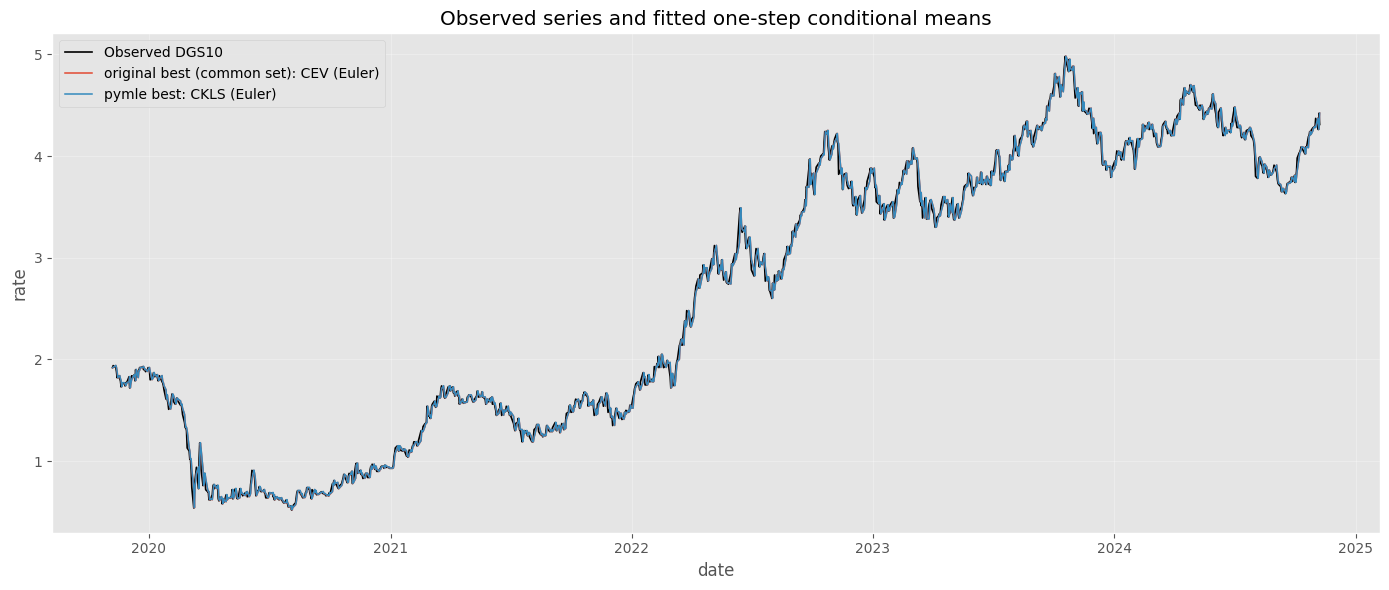

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(rates_df["DATE"], observed_rates, color="black", linewidth=1.2, label="Observed DGS10")
plt.plot(
    rates_df["DATE"],
    original_fitted_mean,
    linewidth=1.1,
    label=f"original best (common set): {best_original_model_name} ({best_original_method_name})"
)
plt.plot(
    rates_df["DATE"],
    pymle_fitted_mean,
    linewidth=1.1,
    label=f"pymle best: {best_pymle_model_name} ({best_pymle_method_name})"
)

plt.title("Observed series and fitted one-step conditional means")
plt.xlabel("date")
plt.ylabel("rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### 10. Итоговые выводы

- Первичный анализ ряда DGS10 показал, что дневные изменения ставки имеют выбросы, не подчиняются нормальному распределению и содержат выраженную точку смены режима в 2020 году

- Среди моделей, оцененных оригинальным кодом, лучшей по AIC и BIC оказалась модель CEV, однако модель CKLS дала очень близкие значения критериев и также хорошо описывает динамику ряда

- Библиотечная оценка через pymle показала, что на общем наборе сравнимых моделей лучшей является модель CKLS, что хорошо согласуется с результатами оригинального кода на том же наборе моделей

- Простые модели BM и GBM заметно уступают CEV и CKLS по критериям качества, а значит хуже отражают структуру реальных процентных ставок

- В целом результаты подтверждают, что для ряда DGS10 более подходящими являются модели с нелинейной диффузией и/или более гибкой структурой дрифта, чем у базовых BM и GBM